## Welcome to my project!

This project aims at quantifying and demonstarting the difference between parametric modeling (e.g. single-factor Gaussian copula mode) versus non-parametric, universal approximators from unsupervised machine learning, as well as combination of both: Machine Learning (ML) + Montecarlo (MC) simulations. This work is inspired by https://arxiv.org/pdf/2202.11060

In [148]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## The data

In order to provide reproducible, I will rely on the data from Kaggle competition Give Me Some Credit (https://www.kaggle.com/c/GiveMeSomeCredit).

In [149]:
# We load & prepare data (Give Me Some Credit) =====
# Put the CSV at: data/cs-training.csv
df = pd.read_csv("data/GiveMeSomeCredit/cs-training.csv")

# Target and features
y_all = df["SeriousDlqin2yrs"].values.reshape(-1, 1)  # (N,1)
X_all = df.drop(columns=["SeriousDlqin2yrs"])
X_all = X_all.select_dtypes(include=[np.number]).values  # we keep numeric only

rng = np.random.default_rng(0)

We check how 'incomplete' the data is

In [150]:
X_df = df.drop(columns=["SeriousDlqin2yrs"], errors="ignore")
X_df = X_df.drop(columns=["Unnamed: 0"], errors="ignore")

# number of rows with ≥1 NaN
n_rows_with_nan = X_df.isna().any(axis=1).sum() # Here we count the number of rows with at least one NaN
n_rows_total = len(X_df)

print(n_rows_with_nan, "rows with at least one NaN")
print(f"{n_rows_with_nan/n_rows_total:.2%} of rows")

29731 rows with at least one NaN
19.82% of rows


## Input
We clean the data first. There are some data points that contain NaN. We use imputer and scaler functions of sci-kit learn to set those NaN to the median value of a given array.

In [151]:
# Impute missing with median, then standardize

imputer = SimpleImputer(strategy="median") #Since the NaNs are undefined, we use the scikit function to replace the value with the median of that column (as a vector)
scaler  = StandardScaler()

X_all = imputer.fit_transform(X_all) #replaces any entry NaN with the median of the of the corresponding column

X_all = scaler.fit_transform(X_all) #rescale each column as x_j->(x_j-mu)/sigma (where sigma and mu correspond to that column)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

#stratify : we split the data in two sets (training and validation). Stratify ensures that both have the same shares of defaults

## The model 

I use a simple neural network activated via ReLu followed by a sigmoid. I also define a forward, entropy loss function and backward propagation (gradient descent).

In [152]:
# =====  Activation functions =====
def relu(Z):
    return np.maximum(0.0, Z)

def sigmoid(Z):
    # numerically stable enough for this use
    return 1.0 / (1.0 + np.exp(-Z))

# ===== 2) He initialization (for ReLU) =====
def he_init(d, H, rng):
    W1 = rng.normal(0.0, np.sqrt(2.0/d), size=(d, H))
    b1 = np.zeros((1, H))
    W2 = rng.normal(0.0, np.sqrt(2.0/H), size=(H, 1))
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2

# ===== 3) Forward pass =====
def forward(X, W1, b1, W2, b2):
    # X: (N, d)
    Z1 = X @ W1 + b1            # (N, H) affine
    A1 = relu(Z1)               # (N, H) nonlinearity
    Z2 = A1 @ W2 + b2           # (N, 1) logit
    Yhat = sigmoid(Z2)          # (N, 1) probability
    cache = (Z1, A1, Z2, Yhat)  # we need these for backprop
    return Yhat, cache

# ===== 4) Binary cross-entropy loss (mean over batch) =====
def bce_loss(Yhat, y, eps=1e-12):
    Yhat = np.clip(Yhat, eps, 1.0 - eps)
    return -(y * np.log(Yhat) + (1 - y) * np.log(1 - Yhat)).mean()

# ===== 5) Backward pass (gradients via chain rule) =====
def backward(X, y, cache, W2):
    Z1, A1, Z2, Yhat = cache
    N = X.shape[0]
    G2 = (Yhat - y) / N               # (N, 1) output error
    dW2 = A1.T @ G2                   # (H, 1)
    db2 = np.sum(G2, axis=0, keepdims=True)   # (1, 1)
    G1 = (G2 @ W2.T) * (Z1 > 0)       # (N, H) elementwise mask for ReLU
    dW1 = X.T @ G1                    # (d, H)
    db1 = np.sum(G1, axis=0, keepdims=True)   # (1, H)
    return dW1, db1, dW2, db2

## Initialize training

In [153]:
# ===== Training loop (mini-batch SGD) with loss history =====

# Define dimensions consistently here (no hard-coding)
d = X_train.shape[1]   # number of features, ie, number of columns
H = 64                 # hidden units (you can try 32 or 128 later)

W1, b1, W2, b2 = he_init(d, H, rng) #We define W1, b1, W2, b2 of the two layered network

train_hist, val_hist = [], []  # store loss per epoch

epochs = 1000
batch_size = 256
lr = 1e-3

n_train = X_train.shape[0]
for ep in range(1, epochs + 1):
    # shuffle indices for this epoch
    idx = rng.permutation(n_train)

    # iterate over mini-batches by index (no in-place array shuffling)
    for start in range(0, n_train, batch_size):
        stop = min(start + batch_size, n_train)
        bidx = idx[start:stop]
        Xb = X_train[bidx]
        yb = y_train[bidx]

        # forward -> loss
        Yhat_b, cache_b = forward(Xb, W1, b1, W2, b2)
        loss_b = bce_loss(Yhat_b, yb)

        # backward -> grads
        dW1, db1, dW2, db2 = backward(Xb, yb, cache_b, W2)

        # SGD update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    # end-epoch: evaluate full train/val loss
    train_pred, _ = forward(X_train, W1, b1, W2, b2)
    val_pred, _   = forward(X_val,   W1, b1, W2, b2)
    train_loss = bce_loss(train_pred, y_train)
    val_loss   = bce_loss(val_pred,   y_val)

    # record for plotting
    train_hist.append(train_loss)
    val_hist.append(val_loss)

    # print every 5 epochs (or first)
    if ep % 5 == 0 or ep == 1:
        print(f"epoch {ep:02d} | train={train_loss:.4f} | val={val_loss:.4f}")

epoch 01 | train=0.3600 | val=0.3588
epoch 05 | train=0.2579 | val=0.2582
epoch 10 | train=0.2464 | val=0.2469
epoch 15 | train=0.2438 | val=0.2442
epoch 20 | train=0.2419 | val=0.2423
epoch 25 | train=0.2404 | val=0.2406
epoch 30 | train=0.2390 | val=0.2392
epoch 35 | train=0.2377 | val=0.2378
epoch 40 | train=0.2365 | val=0.2365
epoch 45 | train=0.2354 | val=0.2353
epoch 50 | train=0.2343 | val=0.2342
epoch 55 | train=0.2332 | val=0.2330
epoch 60 | train=0.2321 | val=0.2320
epoch 65 | train=0.2311 | val=0.2309
epoch 70 | train=0.2301 | val=0.2299
epoch 75 | train=0.2292 | val=0.2289
epoch 80 | train=0.2283 | val=0.2279
epoch 85 | train=0.2273 | val=0.2270
epoch 90 | train=0.2265 | val=0.2260
epoch 95 | train=0.2256 | val=0.2251
epoch 100 | train=0.2248 | val=0.2243
epoch 105 | train=0.2239 | val=0.2234
epoch 110 | train=0.2232 | val=0.2226
epoch 115 | train=0.2224 | val=0.2217
epoch 120 | train=0.2216 | val=0.2210
epoch 125 | train=0.2209 | val=0.2202
epoch 130 | train=0.2202 | val=0

## Plotting

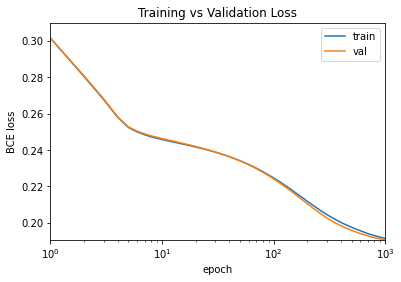

In [154]:
# ===== Plot the loss curves =====
plt.figure()

plt.plot(train_hist, label="train")
plt.plot(val_hist, label="val")
plt.xscale("log")        

ymin = min(min(train_hist), min(val_hist))
ymax = max(max(train_hist), max(val_hist))

plt.ylim(ymin , 0.31 )   # ← AFTER plotting
plt.xlim(1 , epochs )   # ← AFTER plotting


plt.xlabel("epoch")
plt.ylabel("BCE loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

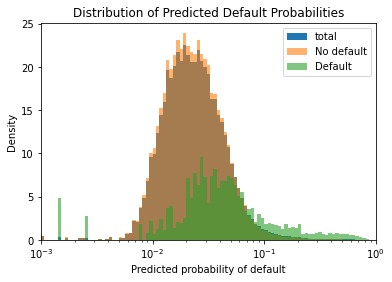

In [161]:
probs_val = forward(X_val, W1, b1, W2, b2)[0]
probs_default    = probs_val[y_val.ravel() == 1]
probs_nondefault = probs_val[y_val.ravel() == 0]

probs = probs_val.ravel()

plt.figure()

plt.hist(probs, bins=np.logspace(-3, 0, 100), density=True, label="total")

plt.hist(probs_nondefault, bins=np.logspace(-3, 0, 100), density=True,
         alpha=0.6, label="No default")

plt.hist(probs_default, bins=np.logspace(-3, 0, 100), density=True,
         alpha=0.6, label="Default")

plt.xlabel("Predicted probability of default")
plt.ylabel("Density")

plt.xscale("log")   
plt.xlim(10**(-3) , 1 )  
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()

plt.show()

In [162]:
bins = np.logspace(-3, 0, 35)
bin_ids = np.digitize(probs, bins)

bin_centers = []
obs_rates = []
counts = []
deviation = []
uncertainty = []
standarized_discr = []

for i in range(1, len(bins)):
    mask = bin_ids == i
    if mask.sum() > 50:   # avoid tiny bins
        pi = np.sqrt(bins[i-1]*bins[i])
        ri = y_val[mask].mean()
        ni = mask.sum()
        deltai = ri - pi
        sigmai = np.sqrt(pi*(1-pi)/ni  )
        
        bin_centers.append( pi )
        obs_rates.append( ri )

        deviation.append( deltai )
        uncertainty.append( sigmai )
        standarized_discr.append( deltai/sigmai )
        counts.append( ni )
        
        #print(y_val[mask].mean())
        #print("center is", np.sqrt(bins[i-1]*bins[i]))
        #print("bin(i-1) is ", bins[i-1])
        #print("bin(i) is ", bins[i])
        #print("average is ", (bins[i]+bins[i-1])/2)


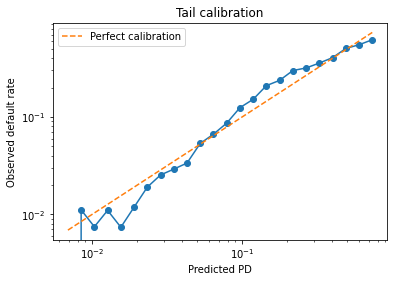

In [163]:
plt.figure()
plt.plot(bin_centers, obs_rates, "o-")
plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted PD")
plt.ylabel("Observed default rate")
plt.legend()
plt.title("Tail calibration")
plt.show()


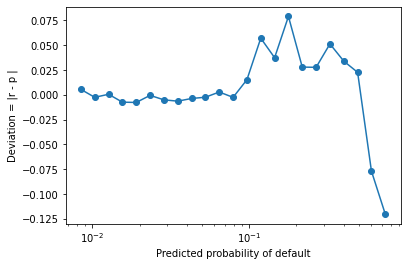

In [92]:
plt.figure()
plt.plot(bin_centers,deviation, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("Deviation = |r - p |")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

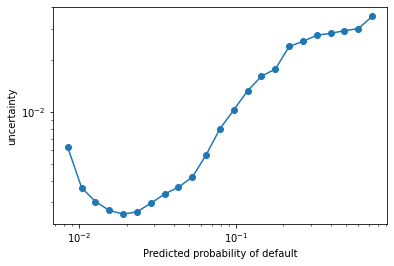

In [93]:
plt.figure()
plt.plot(bin_centers,uncertainty, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("uncertainty")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

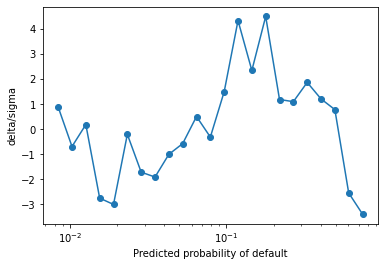

In [94]:
plt.figure()
plt.plot(bin_centers,standarized_discr, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("delta/sigma")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

## We now plot the Receiver Operating Characteristic (ROC) curve

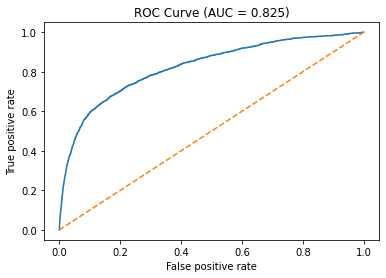

In [143]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

y_true = y_val.ravel()
y_score = probs

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
auc_roc = roc_auc_score(y_true, y_score)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC Curve (AUC = {auc_roc:.3f})")
plt.show()


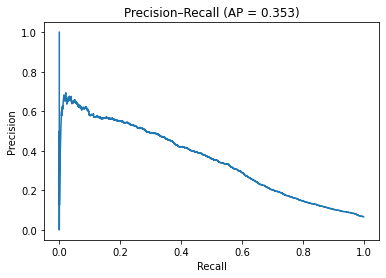

In [134]:
# Precision recall
prec, rec, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall (AP = {ap:.3f})")
plt.show()

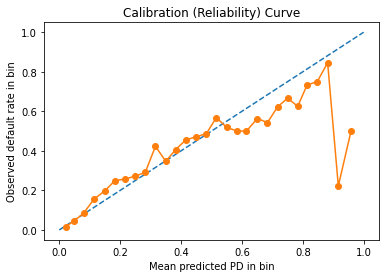

In [137]:
def calib_curve(y_true, y_prob, n_bins=30):
    bins = np.linspace(0, 1, n_bins+1)
    idx = np.digitize(y_prob, bins) - 1
    frac_pos, mean_pred = [], []
    for b in range(n_bins):
        mask = (idx == b)
        if mask.any():
            frac_pos.append(y_true[mask].mean())
            mean_pred.append(y_prob[mask].mean())
    return np.array(mean_pred), np.array(frac_pos)

mp, fp = calib_curve(y_true, y_score, n_bins=30)
plt.figure()
plt.plot([0,1],[0,1],'--')
plt.plot(mp, fp, marker='o')
plt.xlabel("Mean predicted PD in bin")
plt.ylabel("Observed default rate in bin")
plt.title("Calibration (Reliability) Curve")
plt.show()

# TensorFlow implementation
Let's do the same exercise using established libraries

In [147]:
import numpy as np
import tensorflow as tf

# Ensure float32 for TF
X_train_tf = X_train.astype(np.float32)
X_val_tf   = X_val.astype(np.float32)

# Ensure labels are float32 shape (N,1)
y_train_tf = y_train.astype(np.float32).reshape(-1, 1)
y_val_tf   = y_val.astype(np.float32).reshape(-1, 1)

d = X_train_tf.shape[1]
H = 64

# Model: (d -> H ReLU) -> (H -> 1 Sigmoid)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(d,)),
    tf.keras.layers.Dense( # this is the first layer
        H,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal()), #HeNormal initializes Wi's and b's with gaussian noise
    tf.keras.layers.Dense(1, activation="sigmoid") #second layer
])

# Compile: BCE + Adam optimizer
lr = 1e-3
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=tf.keras.losses.BinaryCrossentropy(), #we use the binary cross entropy
    metrics=[tf.keras.metrics.AUC(name="auc_roc", curve="ROC"),
             tf.keras.metrics.AUC(name="auc_pr", curve="PR")]
)

# Train
history = model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=200,
    batch_size=256,
    verbose=1
)

# Predict probabilities (like in forward(...))
probs_val_tf = model.predict(X_val_tf, batch_size=4096).ravel()


Epoch 1/200
469/469 [==============================] - 1s 1ms/step - loss: 0.2540 - auc_roc: 0.6275 - auc_pr: 0.1078 - val_loss: 0.2206 - val_auc_roc: 0.7319 - val_auc_pr: 0.2534
Epoch 2/200
469/469 [==============================] - 0s 976us/step - loss: 0.2085 - auc_roc: 0.7708 - auc_pr: 0.2965 - val_loss: 0.1982 - val_auc_roc: 0.8077 - val_auc_pr: 0.3320
Epoch 3/200
469/469 [==============================] - 0s 959us/step - loss: 0.1961 - auc_roc: 0.8103 - auc_pr: 0.3358 - val_loss: 0.1925 - val_auc_roc: 0.8244 - val_auc_pr: 0.3478
Epoch 4/200
469/469 [==============================] - 0s 969us/step - loss: 0.1926 - auc_roc: 0.8203 - auc_pr: 0.3487 - val_loss: 0.1906 - val_auc_roc: 0.8267 - val_auc_pr: 0.3558
Epoch 5/200
469/469 [==============================] - 0s 992us/step - loss: 0.1911 - auc_roc: 0.8249 - auc_pr: 0.3553 - val_loss: 0.1895 - val_auc_roc: 0.8293 - val_auc_pr: 0.3603
Epoch 6/200
469/469 [==============================] - 0s 969us/step - loss: 0.1903 - auc_roc: 0.

469/469 [==============================] - 0s 984us/step - loss: 0.1862 - auc_roc: 0.8360 - auc_pr: 0.3744 - val_loss: 0.1867 - val_auc_roc: 0.8367 - val_auc_pr: 0.3688
Epoch 47/200
469/469 [==============================] - 0s 964us/step - loss: 0.1860 - auc_roc: 0.8362 - auc_pr: 0.3761 - val_loss: 0.1873 - val_auc_roc: 0.8362 - val_auc_pr: 0.3644
Epoch 48/200
469/469 [==============================] - 0s 974us/step - loss: 0.1862 - auc_roc: 0.8362 - auc_pr: 0.3739 - val_loss: 0.1867 - val_auc_roc: 0.8370 - val_auc_pr: 0.3672
Epoch 49/200
469/469 [==============================] - 0s 963us/step - loss: 0.1860 - auc_roc: 0.8366 - auc_pr: 0.3770 - val_loss: 0.1870 - val_auc_roc: 0.8370 - val_auc_pr: 0.3664
Epoch 50/200
469/469 [==============================] - 0s 969us/step - loss: 0.1860 - auc_roc: 0.8368 - auc_pr: 0.3762 - val_loss: 0.1873 - val_auc_roc: 0.8344 - val_auc_pr: 0.3666
Epoch 51/200
469/469 [==============================] - 0s 943us/step - loss: 0.1860 - auc_roc: 0.8367 

469/469 [==============================] - 0s 977us/step - loss: 0.1849 - auc_roc: 0.8393 - auc_pr: 0.3830 - val_loss: 0.1877 - val_auc_roc: 0.8345 - val_auc_pr: 0.3677
Epoch 92/200
469/469 [==============================] - 0s 978us/step - loss: 0.1848 - auc_roc: 0.8401 - auc_pr: 0.3833 - val_loss: 0.1874 - val_auc_roc: 0.8361 - val_auc_pr: 0.3655
Epoch 93/200
469/469 [==============================] - 0s 996us/step - loss: 0.1849 - auc_roc: 0.8394 - auc_pr: 0.3833 - val_loss: 0.1867 - val_auc_roc: 0.8376 - val_auc_pr: 0.3697
Epoch 94/200
469/469 [==============================] - 0s 979us/step - loss: 0.1848 - auc_roc: 0.8393 - auc_pr: 0.3821 - val_loss: 0.1872 - val_auc_roc: 0.8367 - val_auc_pr: 0.3701
Epoch 95/200
469/469 [==============================] - 0s 980us/step - loss: 0.1848 - auc_roc: 0.8395 - auc_pr: 0.3827 - val_loss: 0.1876 - val_auc_roc: 0.8367 - val_auc_pr: 0.3666
Epoch 96/200
469/469 [==============================] - 0s 993us/step - loss: 0.1849 - auc_roc: 0.8398 

469/469 [==============================] - 1s 1ms/step - loss: 0.1839 - auc_roc: 0.8426 - auc_pr: 0.3858 - val_loss: 0.1863 - val_auc_roc: 0.8405 - val_auc_pr: 0.3666
Epoch 137/200
469/469 [==============================] - 0s 1ms/step - loss: 0.1839 - auc_roc: 0.8428 - auc_pr: 0.3860 - val_loss: 0.1869 - val_auc_roc: 0.8385 - val_auc_pr: 0.3669
Epoch 138/200
469/469 [==============================] - 1s 1ms/step - loss: 0.1839 - auc_roc: 0.8433 - auc_pr: 0.3859 - val_loss: 0.1864 - val_auc_roc: 0.8402 - val_auc_pr: 0.3668
Epoch 139/200
469/469 [==============================] - 0s 1ms/step - loss: 0.1838 - auc_roc: 0.8432 - auc_pr: 0.3867 - val_loss: 0.1861 - val_auc_roc: 0.8409 - val_auc_pr: 0.3684
Epoch 140/200
469/469 [==============================] - 0s 1ms/step - loss: 0.1837 - auc_roc: 0.8428 - auc_pr: 0.3879 - val_loss: 0.1867 - val_auc_roc: 0.8399 - val_auc_pr: 0.3657
Epoch 141/200
469/469 [==============================] - 0s 955us/step - loss: 0.1837 - auc_roc: 0.8434 - auc

Epoch 181/200
469/469 [==============================] - 0s 1ms/step - loss: 0.1826 - auc_roc: 0.8473 - auc_pr: 0.3902 - val_loss: 0.1857 - val_auc_roc: 0.8426 - val_auc_pr: 0.3721
Epoch 182/200
469/469 [==============================] - 0s 951us/step - loss: 0.1826 - auc_roc: 0.8474 - auc_pr: 0.3907 - val_loss: 0.1849 - val_auc_roc: 0.8455 - val_auc_pr: 0.3684
Epoch 183/200
469/469 [==============================] - 0s 1ms/step - loss: 0.1826 - auc_roc: 0.8472 - auc_pr: 0.3887 - val_loss: 0.1853 - val_auc_roc: 0.8451 - val_auc_pr: 0.3686
Epoch 184/200
469/469 [==============================] - 0s 955us/step - loss: 0.1825 - auc_roc: 0.8474 - auc_pr: 0.3912 - val_loss: 0.1855 - val_auc_roc: 0.8449 - val_auc_pr: 0.3693
Epoch 185/200
469/469 [==============================] - 0s 979us/step - loss: 0.1824 - auc_roc: 0.8476 - auc_pr: 0.3928 - val_loss: 0.1853 - val_auc_roc: 0.8444 - val_auc_pr: 0.3695
Epoch 186/200
469/469 [==============================] - 0s 1ms/step - loss: 0.1824 - auc

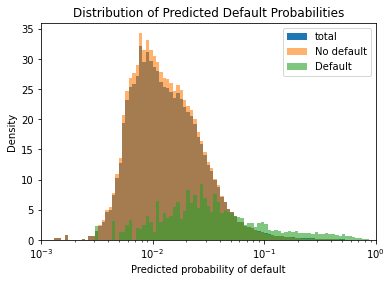

In [171]:
probs_default_tf    = probs_val_tf[y_val_tf.ravel() == 1]
probs_nondefault_tf = probs_val_tf[y_val_tf.ravel() == 0]

probs_tf = probs_val_tf.ravel()

plt.figure()

plt.hist(probs_tf, bins=np.logspace(-3, 0, 100), density=True, label="total")

plt.hist(probs_nondefault_tf, bins=np.logspace(-3, 0, 100), density=True,
         alpha=0.6, label="No default")

plt.hist(probs_default_tf, bins=np.logspace(-3, 0, 100), density=True,
         alpha=0.6, label="Default")

plt.xlabel("Predicted probability of default")
plt.ylabel("Density")

plt.xscale("log")   
plt.xlim(10**(-3) , 1 )  
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()

plt.show()

In [167]:
bins = np.logspace(-3, 0, 35)
bin_ids = np.digitize(probs_tf, bins)

bin_centers_tf = []
obs_rates_tf = []
counts_tf = []
deviation_tf = []
uncertainty_tf = []
standarized_discr_tf = []

for i in range(1, len(bins)):
    mask = bin_ids == i
    if mask.sum() > 50:   # avoid tiny bins
        pi = np.sqrt(bins[i-1]*bins[i])
        ri = y_val_tf[mask].mean()
        ni = mask.sum()
        deltai = ri - pi
        sigmai = np.sqrt(pi*(1-pi)/ni  )
        
        bin_centers_tf.append( pi )
        obs_rates_tf.append( ri )

        deviation_tf.append( deltai )
        uncertainty_tf.append( sigmai )
        standarized_discr_tf.append( deltai/sigmai )
        counts_tf.append( ni )
        
        #print(y_val[mask].mean())
        #print("center is", np.sqrt(bins[i-1]*bins[i]))
        #print("bin(i-1) is ", bins[i-1])
        #print("bin(i) is ", bins[i])
        #print("average is ", (bins[i]+bins[i-1])/2)

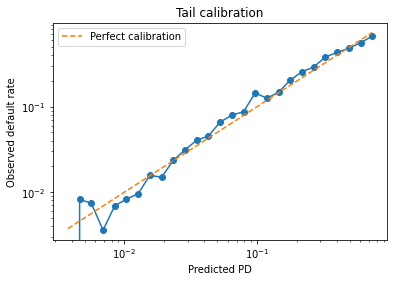

In [168]:
plt.figure()
plt.plot(bin_centers_tf, obs_rates_tf, "o-")
plt.plot(bin_centers_tf, bin_centers_tf, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted PD")
plt.ylabel("Observed default rate")
plt.legend()
plt.title("Tail calibration")
plt.show()

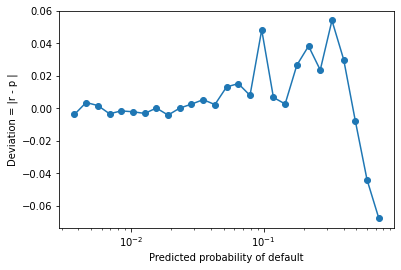

In [169]:
plt.figure()
plt.plot(bin_centers_tf,deviation_tf, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("Deviation = |r - p |")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

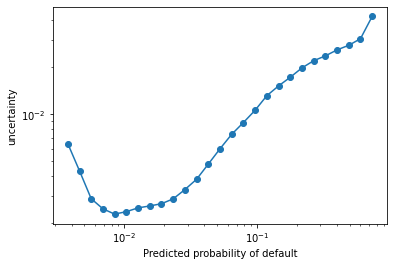

In [170]:
plt.figure()
plt.plot(bin_centers_tf,uncertainty_tf, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("uncertainty")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

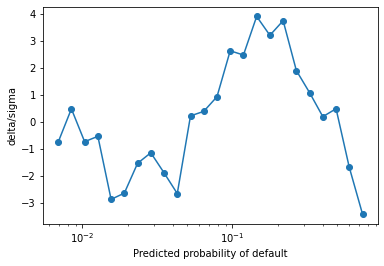

In [172]:
plt.figure()
plt.plot(bin_centers,standarized_discr, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("delta/sigma")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()